In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Show first rows
print("First 5 rows")
print(df.head())

print("\nShape of dataset")
print(df.shape)

print("\nColumn names")
print(df.columns)

print("\nData types")
print(df.dtypes)

print("\nMissing values")
print(df.isnull().sum())

First 5 rows
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        

In [2]:
print("Dataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

In [3]:
print(df["Churn"].value_counts())

print("\nChurn Percentage")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [4]:
categorical_cols = df.select_dtypes(include=['object']).columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumeric Columns:")
print(numeric_cols)

Categorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

Numeric Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [5]:
# Check unique values that might be blank
print((df["TotalCharges"] == " ").sum())

11


In [6]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values created
print(df["TotalCharges"].isnull().sum())

11


In [7]:
df = df.dropna()

print("New shape after dropping rows:")
print(df.shape)

New shape after dropping rows:
(7032, 21)


In [8]:
df = df.drop("customerID", axis=1)

print(df.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [9]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [10]:
print(df.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

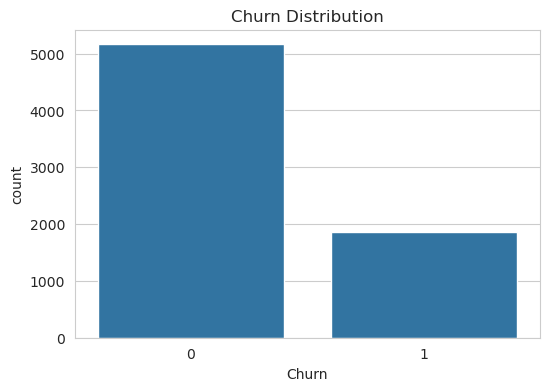

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

print(df['Churn'].value_counts(normalize=True)*100)

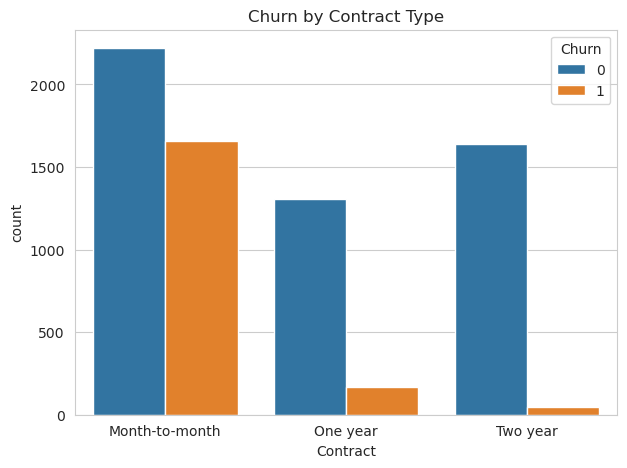

In [13]:
plt.figure(figsize=(7,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

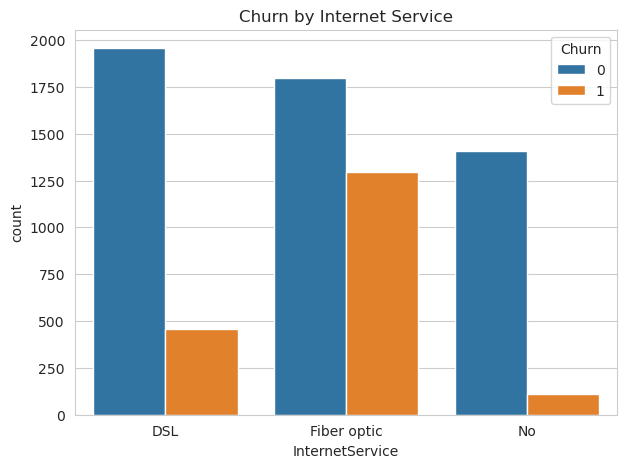

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

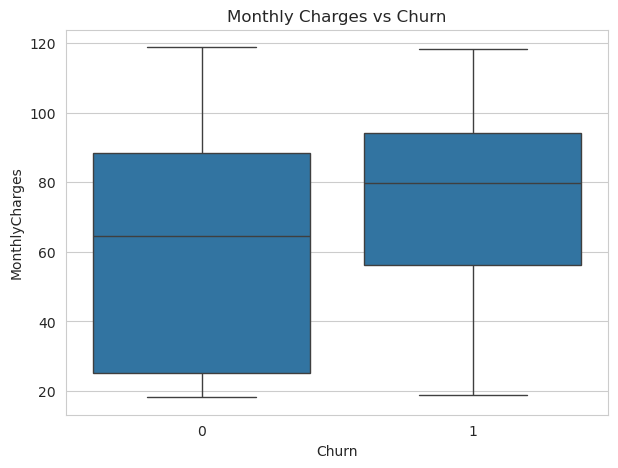

In [15]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

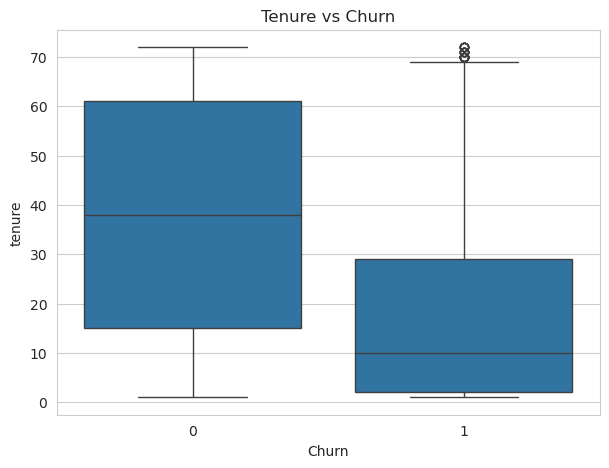

In [16]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

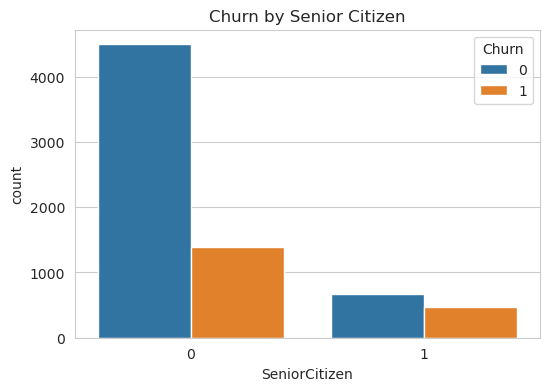

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Churn by Senior Citizen")
plt.show()

In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)
df_encoded.head()

(7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [19]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [22]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
print("Logistic Regression Performance")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_pred_log))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Performance
Accuracy: 0.7882018479033405
Precision: 0.6225806451612903
Recall: 0.516042780748663
F1 Score: 0.564327485380117
ROC AUC: 0.7013902190287361

Confusion Matrix
[[916 117]
 [181 193]]


In [24]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [25]:
print("Random Forest Performance")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Performance
Accuracy: 0.7917555081734187
Precision: 0.6451612903225806
Recall: 0.48128342245989303
F1 Score: 0.5513016845329249
ROC AUC: 0.6927230277836736

Confusion Matrix
[[934  99]
 [194 180]]


In [26]:
from xgboost import XGBClassifier

In [27]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [28]:
print("XGBoost Performance")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Performance
Accuracy: 0.7924662402274343
Precision: 0.6339869281045751
Recall: 0.5187165775401069
F1 Score: 0.5705882352941176
ROC AUC: 0.7051472529520476

Confusion Matrix
[[921 112]
 [180 194]]


In [29]:
from catboost import CatBoostClassifier

In [30]:
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=0
)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)

In [31]:
print("CatBoost Performance")

print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat))
print("Recall:", recall_score(y_test, y_pred_cat))
print("F1 Score:", f1_score(y_test, y_pred_cat))
print("ROC AUC:", roc_auc_score(y_test, y_pred_cat))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_cat))

CatBoost Performance
Accuracy: 0.7860696517412935
Precision: 0.622895622895623
Recall: 0.4946524064171123
F1 Score: 0.5514157973174366
ROC AUC: 0.6931151673905503

Confusion Matrix
[[921 112]
 [189 185]]


In [32]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
10,InternetService_Fiber optic,0.434356
25,Contract_Two year,0.168594
24,Contract_One year,0.101895
11,InternetService_No,0.073481
1,tenure,0.025766
23,StreamingMovies_Yes,0.023664
13,OnlineSecurity_Yes,0.014167
19,TechSupport_Yes,0.014050
28,PaymentMethod_Electronic check,0.013906
21,StreamingTV_Yes,0.012953


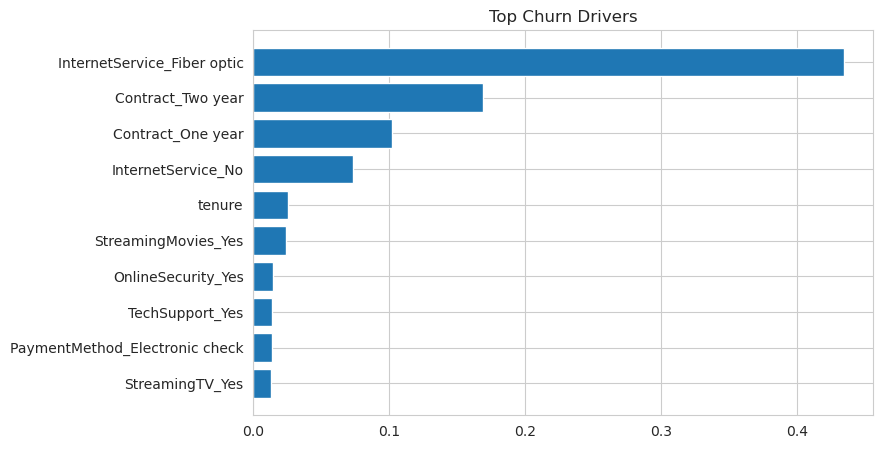

In [33]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top Churn Drivers")
plt.show()

In [34]:
churn_prob = xgb_model.predict_proba(X_test)[:,1]

In [44]:
high_risk = X_test.copy()
high_risk["churn_probability"] = churn_prob

high_risk_customers = high_risk[high_risk["churn_probability"] > 0.7]
high_risk_customers.to_csv("high_risk_customers.csv", index=False)
print(high_risk_customers.shape)

(123, 31)


In [45]:
import joblib

joblib.dump(xgb_model, "churn_model.pkl")

['churn_model.pkl']

In [46]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.to_csv("feature_importance.csv", index=False)

feature_importance.head(10)

,Feature,Importance
10,InternetService_Fiber optic,0.434356
25,Contract_Two year,0.168594
24,Contract_One year,0.101895
11,InternetService_No,0.073481
1,tenure,0.025766
23,StreamingMovies_Yes,0.023664
13,OnlineSecurity_Yes,0.014167
19,TechSupport_Yes,0.014050
28,PaymentMethod_Electronic check,0.013906
21,StreamingTV_Yes,0.012953
